# Deep Learning for Brain Tumor Detection in X-ray Scans



<a name='T'></a>

<p style="padding: 20px;
          background-color: #0044CC;
          font-family: 'Arial', sans-serif;
          color: #FFFFFF;
          font-size: 280%;
          text-align: center;
          border-radius: 25px 5px;">
🔬 AI-Powered Medical Image Analysis 🏥
</p>

<p style="font-family: 'Arial', sans-serif;
          color: #333333;
          font-size: 160%;
          text-align: center;">
📅 March 4, 2025
</p>


## <span style='border-left: 4px solid #FF5733; padding-left: 10px;'> 📖 Table of Contents </span> 📌

1. 🔍 [`About The Data`](#data)
2. 🛠 [`Imports & Setup`](#imports)
3. 📂 [`Data Loading & Preprocessing`](#import_data)
4. 📊 [`Data Visualization`](#vis)
5. 🔄 [`Data Processing`](#DP)
6. 🏗 [`First CNN Model`](#CNN)
7. 🏗 [`Pretrained CNN Model`](#CNN2)
8. 📈 [`Comparison of Models`](#compare)
9. ✅ [`End of Notebook`](#end)
  


<a name='data'>

# 1️⃣ <span style='color:#007BFF'>|</span> 🧠 **About The Data**  

## 📍 **1.1 | What is a Brain Tumor?** 🏥
A **brain tumor** refers to an abnormal collection or mass of cells within the brain. The skull, which encloses the brain, has limited space, and any growth within this confined area can lead to complications. Brain tumors can be **cancerous (malignant)** or **noncancerous (benign)**. As benign or malignant tumors grow, they can increase the pressure inside the skull. This elevated pressure can cause brain damage and pose a **life-threatening risk**.

---

### 🎯 **1.1.1 | Importance of Brain Tumor Classification** 🎗
✅ Early detection and classification of brain tumors are **crucial** in medical imaging.  
✅ Accurate classification **helps doctors** choose the best treatment options.  
✅ It has the **potential to save lives** through **early intervention**.

---

### 🛠 **1.1.2 | Methods Used** 🧪
🔹 Deep learning has **revolutionized healthcare**, making diagnoses **more accurate**.  
🔹 According to the **World Health Organization (WHO)**, a good diagnosis requires:
   - **Tumor detection** 🏥  
   - **Identifying tumor location** 📍  
   - **Classification based on malignancy, grade, and type** 🏷  

👉 **This study uses a Convolutional Neural Network (CNN)-based approach** for tumor classification  in **X-ray Scans**. Instead of multiple models, a **single CNN model** is used for different classification tasks.

---

## 🔍 **1.2 | Project Workflow** 🏗  
This project follows three main steps:  

1️⃣ **Implementing a Custom CNN Model** 🛠  
   - A **Convolutional Neural Network (CNN)** is built **from scratch** to classify brain tumors.  

2️⃣ **Applying a Pretrained Model** 📦  
   - A **transfer learning approach** is used by applying a **pretrained CNN model** (VGG16).  

3️⃣ **Comparing the Results** 📊  
   - The performance of both models is compared in terms of **accuracy, precision, recall, and F1-score**.  

---

## 📂 **1.3 | About the Dataset** 📊
🧠 Brain Tumor Dataset

This dataset contains X-ray images of the brain from patients diagnosed with brain tumors.

📌 Context:

The dataset consists of scanned X-ray images of patients’ brains, helping in the detection and classification of brain tumors. It is structured to support machine learning and deep learning applications in medical imaging.


📂 Content:

The dataset consists of scanned X-ray images of patients’ brains, helping in the detection and classification of brain tumors. It is structured to support deep learning applications in medical imaging.

It consists of two categories:

✅**Healthy:** Images of normal brain scans.

✅**Brain Tumor:** Images of brain scans with tumors.



📢 Acknowledgements:

This dataset is made possible through contributions from the medical and data science communities.


💡 Inspiration:

With access to this dataset, the global data science community can develop models to improve brain tumor detection and assist in early diagnosis. What innovative solutions can be created using this data? 🚀


🔗 [**Brain Tumor Dataset on Kaggle**](https://www.kaggle.com/datasets/preetviradiya/brian-tumor-dataset)  

---


<a name='imports'>

# 📦 2. <span style='color:#007BFF'>|</span> 🧠 **Imports & Setup**  

In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import Keras components for deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
# Hyperparameter tuning library
import keras_tuner as kt


<a name='import_data'>

# 📂 3. <span style='color:#007BFF'>|</span> 🧠 **Data Loading & Preprocessing**  

In [2]:
# Define dataset path
dataset_path = r"C:\Users\yosrc\Downloads\Brain Tumor Data Set\Brain Tumor Data Set"

# Define categories for classification (Healthy vs Tumor)
categories = ["Healthy", "Brain Tumor"]

# Image size for resizing all images
IMG_SIZE = 224   # VGG16 requires 224x224 input

# List images and labels
data = []
labels = []

for category in categories:
    path = os.path.join(dataset_path, category)
    label = categories.index(category)  # 0: Healthy, 1: Tumor
    for img_name in os.listdir(path):
        img = tf.keras.utils.load_img(os.path.join(path, img_name), target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img)
        data.append(img_array)
        labels.append(label)

# Convert to NumPy arrays
data = np.array(data) / 255.0  # Normalize
labels = np.array(labels)

# One-hot encoding for categorical classification
labels_categorical = to_categorical(labels, num_classes=2)


**📊 3.2 | Image Count per Class**

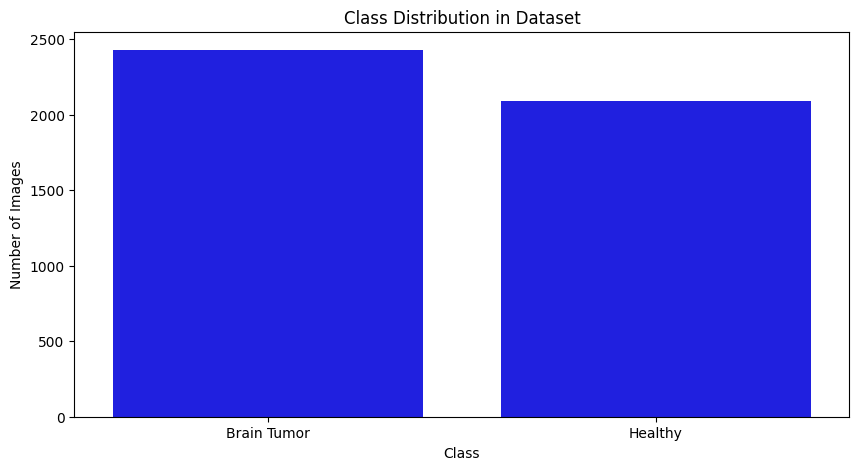

In [29]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the 'Brain Tumor Data Set' folder
dataset_path = r"C:\Users\yosrc\Downloads\Brain Tumor Data Set\Brain Tumor Data Set"

# Function to count images per class
def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):  # Check if it's a directory (class)
            class_counts[class_name] = len([img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.png', '.jpeg'))])
    return class_counts

# Count images for each class
image_counts = count_images_per_class(dataset_path)

# Convert counts to lists
labels = list(image_counts.keys())
image_values = list(image_counts.values())

# Plot class distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=image_values, color='blue')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Dataset")
plt.show()


**🖼 3.3 | Display Sample Images**

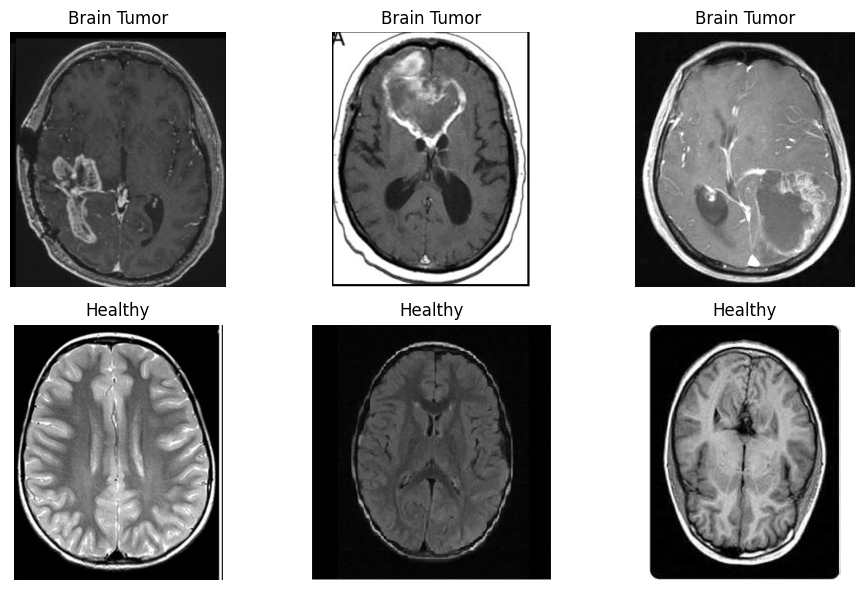

In [30]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Define the correct path to the dataset
dataset_path = r"C:\Users\yosrc\Downloads\Brain Tumor Data Set\Brain Tumor Data Set"

# Function to display images from each class
def show_images_per_class(directory, num_samples=3):
    classes = os.listdir(directory)  # 'Healthy', 'Brain Tumor'
    plt.figure(figsize=(10, len(classes) * 3))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(directory, class_name)
        image_files = os.listdir(class_path)
        sample_images = random.sample(image_files, min(num_samples, len(image_files)))

        for j, image_name in enumerate(sample_images):
            img_path = os.path.join(class_path, image_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert image to RGB

            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{class_name}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Show images from the dataset
show_images_per_class(dataset_path)


**📐 3.4 | Image Size Distribution**

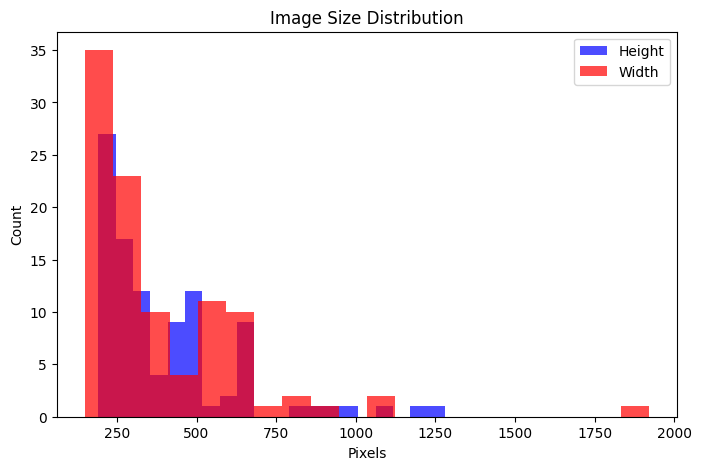

In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the correct path to the dataset
train_dir = r"C:\Users\yosrc\Downloads\Brain Tumor Data Set\Brain Tumor Data Set"

# Initialize an empty list to collect image sizes
image_shapes = []

# Collect image sizes from the 'Healthy' and 'Brain Tumor' categories
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    # Only process directories
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path)[:50]:  # Limit to avoid overloading
            img_path = os.path.join(class_path, image_name)
            img = cv2.imread(img_path)
            if img is not None:
                image_shapes.append(img.shape[:2])  # Only height & width

# Convert to numpy for easy analysis
image_shapes = np.array(image_shapes)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(image_shapes[:, 0], bins=20, alpha=0.7, label="Height", color="blue")
plt.hist(image_shapes[:, 1], bins=20, alpha=0.7, label="Width", color="red")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.title("Image Size Distribution")
plt.legend()
plt.show()


# **Image Size Distribution Analysis**
Before training our model, we analyzed the distribution of image sizes in our dataset to assess the need for preprocessing. The histogram above illustrates the distribution of image widths and heights.

# Observations:
**Dominant Image Size (~200 pixels)**

*  The most frequent image size in the dataset is around 200 pixels for both width and height.
* This indicates that many images are relatively small, which could affect model performance if not properly resized.

**Significant Presence of Small Images (<300 pixels)**

*  A large portion of images falls within the 100-300 pixel range, with a peak around 200 pixels.
* Such small images may lead to poor feature extraction and impact model accuracy, especially in CNN-based models.

**Moderate Occurrence of Medium-Sized Images (~500-600 pixels)**

*  A noticeable number of images are within the 500-600 pixel range, showing a secondary peak in the distribution.

* These images might have originated from a different source or were resized before being added to the dataset.

**Outliers (>800 pixels)**

*   Only a small number of images exceed 800 pixels in either width or height.

* These larger images could increase computational cost without necessarily improving model performance.

# Preprocessing Decision: Resizing to 224x224
To ensure a consistent input size for our deep learning model and improve computational efficiency, we resized all images to 224x224 pixels.
This follows the standard input size of CNN architectures such as ResNet, VGG, and MobileNet, ensuring uniform feature extraction across the dataset.

By applying this preprocessing step, we eliminate variations in image size, making our dataset more uniform and improving model generalization.


1.3 Splitting Data into Train and Test Sets

In [3]:
X_train, X_test, y_train, y_test = train_test_split(data, labels_categorical, test_size=0.2, random_state=42, stratify=labels)


1.4 Data Augmentation

To improve generalization, we apply transformations such as rotations, zooms, and flips.

In [4]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)


Step 2: Using a Pre-Trained Model (VGG16)

2.1 Loading VGG16

Since we uploaded the VGG16 weights manually, we load it as follows:

<a name='vgg16'></a>  

# 🏗 **Why VGG16 for Brain Tumor Classification?**  

## 🔍  Justification for Choosing VGG16 📌  
We chose **VGG16** as our **pretrained model** due to its **strong feature extraction capabilities**, making it highly suitable for **medical image classification**.  
While VGG16 has been widely applied in tasks like **pneumonia detection in chest X-rays** and **diabetic retinopathy classification**, its ability to recognize **complex patterns** allows us to effectively classify **brain tumors in MRI scans**.  

---

### ✅  Advantages of VGG16 for MRI-based Tumor Detection  

🔹 **Proven Accuracy** – VGG16’s **well-structured architecture** makes it highly effective in detecting key features in **MRI scans**.  
🔹 **Efficient Feature Extraction** – Its deep **convolutional layers** capture **subtle patterns** in medical images.  
🔹 **Pretrained on ImageNet** – Since it has been trained on **millions of images**, VGG16 provides a **strong foundation** for recognizing important features in MRI scans.  
🔹 **Optimized for Transfer Learning** – Using a **pretrained model** speeds up training and improves accuracy **even with limited medical datasets**.  

---

### 🚀  Why Not Deeper Models Like ResNet or EfficientNet? 

🔹 **Computational Efficiency** – VGG16 strikes a balance between **accuracy and computational cost**, making it **easier to fine-tune** on MRI scans.  
🔹 **Simplicity & Stability** – Unlike deeper models, **VGG16’s straightforward architecture** makes it **easier to interpret and train** for medical applications.  
🔹 **Proven Success in Medical Imaging** – Numerous studies have shown that **VGG16 performs exceptionally well** in detecting diseases using medical imaging datasets.  

---

### 📊  How VGG16 Enhances Brain Tumor Classification?  

✅ **Extracts low-level and high-level X-RAY features** – Identifies patterns such as **tumor texture, shape, and size**.  
✅ **Fine-tuned for X-RAY Scans** – Adapts to **grayscale medical images**, learning essential tumor-specific features.  
✅ **Prevents Overfitting** – By leveraging pretrained weights, it improves **generalization** on unseen medical images.  

---

### 🔥 **Conclusion**  

By selecting **VGG16**, we **leverage transfer learning** to **enhance accuracy** while keeping **computational requirements manageable**.  
Its **effectiveness in medical imaging** makes it a **robust, well-tested, and efficient CNN model** for **brain tumor classification in X-RAY scans**. 🚀  


In [ ]:
vgg16_weights_path = r"C:\Users\yosrc\Downloads\vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
base_model = VGG16(weights=vgg16_weights_path, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

2.2 Adding Custom Layers

In [12]:
model_vgg = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # 2 classes (Healthy, Tumor)
])

# Freeze the base model
base_model.trainable = False


2.3 Compiling the Model

In [13]:
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


2.4 Training with Early Stopping

In [14]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_vgg = model_vgg.fit(train_generator, validation_data=(X_test, y_test), epochs=10, batch_size=16, callbacks=[early_stopping])


C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 706s 6s/step - accuracy: 0.5777 - loss: 0.6840 - val_accuracy: 0.8033 - val_loss: 0.4825
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 696s 6s/step - accuracy: 0.7510 - loss: 0.5113 - val_accuracy: 0.8402 - val_loss: 0.3929
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 701s 6s/step - accuracy: 0.7958 - loss: 0.4294 - val_accuracy: 0.8576 - val_loss: 0.3442
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 712s 6s/step - accuracy: 0.8280 - loss: 0.3886 - val_accuracy: 0.8685 - val_loss: 0.3228
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 711s 6s/step - accuracy: 0.8422 - loss: 0.3588 - val_accuracy: 0.8804 - val_loss: 0.2962
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 704s 6s/step - accuracy: 0.8560 - loss: 0.3478 - val_accuracy: 0.8902 - val_loss: 0.2752
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 703s 6s/step - accuracy: 0.8550 - loss: 0.3190 - val_accuracy: 0.8815 - val_loss: 0.2663
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 758s 7s/step - accuracy: 0.8677 - loss: 0.3052 - val_accu

Step 3: Developing a Custom CNN Model

3.1 Defining the CNN Architecture

In [15]:
cnn_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolutional block
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),# Pooling to reduce size

    # Second convolutional block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Third convolutional block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Fully connected layers
    Flatten(),  # Flattening feature maps into a vector
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout to reduce overfitting
    Dense(2, activation='softmax')  # Output layer (2 classes)
])


3.2 Choosing the Optimizer

We use RMSprop instead of Adam because:

RMSprop adapts learning rates per weight, making it effective for image-related tasks.
It prevents drastic oscillations in gradient updates.

maram

In [16]:
cnn_model.compile(optimizer=RMSprop(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


3.3 Handling Class Imbalance

In [17]:
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}


3.4 Training with Early Stopping

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 655ms/step - accuracy: 0.5517 - loss: 0.6803 - val_accuracy: 0.6620 - val_loss: 0.5812
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 79s 682ms/step - accuracy: 0.6840 - loss: 0.6093 - val_accuracy: 0.7641 - val_loss: 0.5169
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 75s 654ms/step - accuracy: 0.7330 - loss: 0.5701 - val_accuracy: 0.7935 - val_loss: 0.4855
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7375 - loss: 0.5539 - val_accuracy: 0.7978 - val_loss: 0.4640
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.7576 - loss: 0.5280 - val_accuracy: 0.7870 - val_loss: 0.4665
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.7427 - loss: 0.5298 - val_accuracy: 0.7522 - val_loss: 0.4919
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.7709 - loss: 0.4963 - val_accuracy: 0.8087 - val_loss: 0.4274
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7848 - loss: 0.4844 - va

Step 4: Evaluation and Comparison

4.1 Evaluating the VGG16 Model


29/29 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step
VGG16 Model Performance:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       417
           1       0.92      0.87      0.90       503

    accuracy                           0.89       920
   macro avg       0.89      0.89      0.89       920
weighted avg       0.89      0.89      0.89       920



<Axes: >

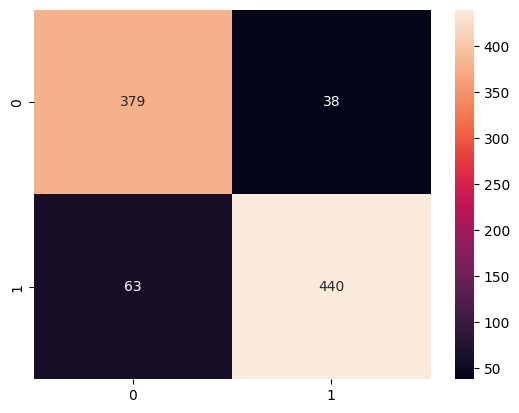

In [19]:
y_pred_vgg = np.argmax(model_vgg.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("VGG16 Model Performance:")
print(classification_report(y_true, y_pred_vgg))
sns.heatmap(confusion_matrix(y_true, y_pred_vgg), annot=True, fmt='d')


4.2 Evaluating the Custom CNN Model

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step 
Custom CNN Model Performance:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       417
           1       0.82      0.83      0.83       503

    accuracy                           0.81       920
   macro avg       0.81      0.81      0.81       920
weighted avg       0.81      0.81      0.81       920



<Axes: >

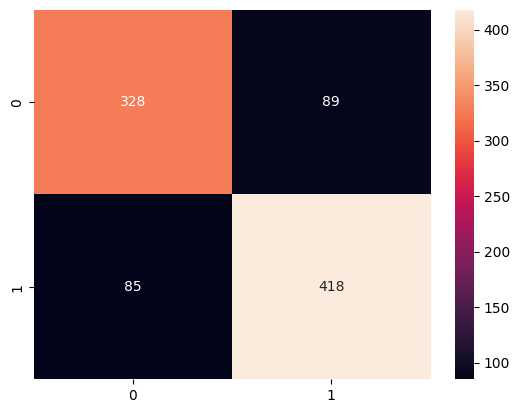

In [20]:
y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)

print("Custom CNN Model Performance:")
print(classification_report(y_true, y_pred_cnn))
sns.heatmap(confusion_matrix(y_true, y_pred_cnn), annot=True, fmt='d')


4.3 Plotting Training Curves

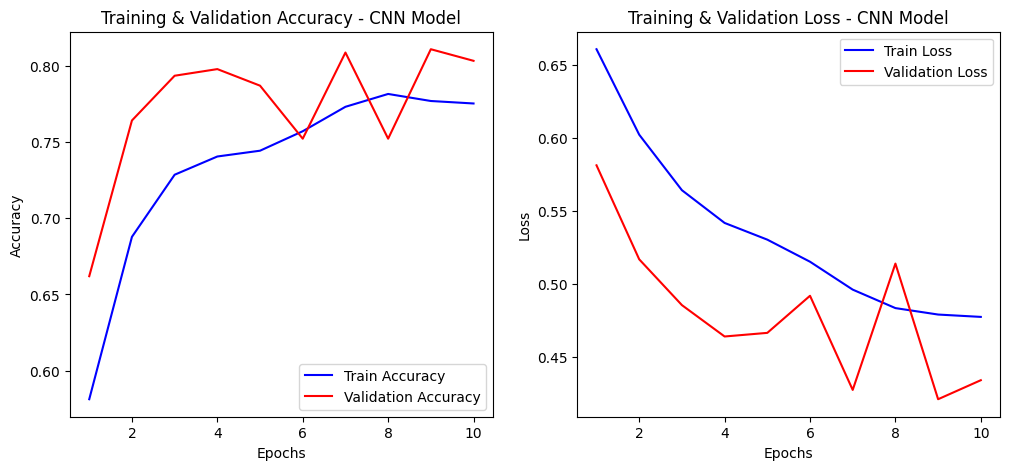

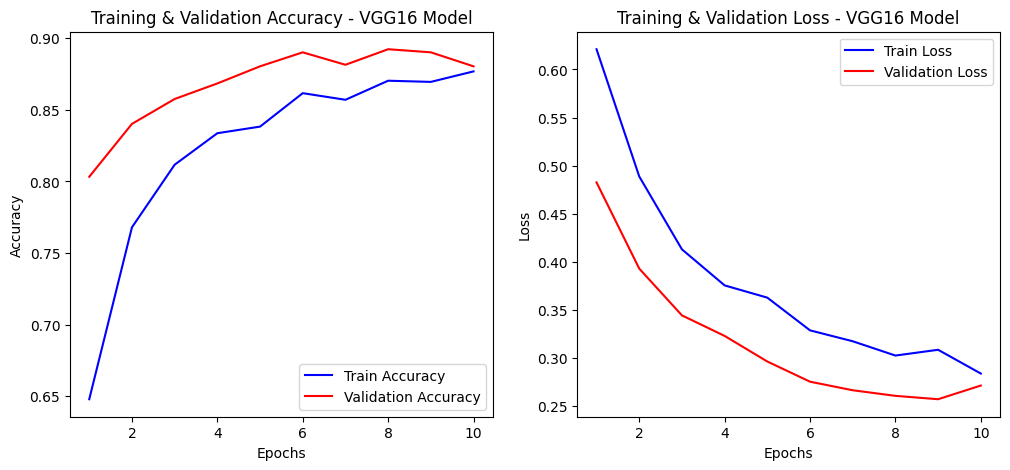

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Function to plot training and validation curves for accuracy and loss
def plot_training_history(history, title):
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy Plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], 'b', label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'r', label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"Training & Validation Accuracy - {title}")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'b', label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Training & Validation Loss - {title}")
    plt.legend()

    plt.show()

# Plot training history for CNN and VGG16
plot_training_history(history_cnn, "CNN Model")  # CNN history
plot_training_history(history_vgg, "VGG16 Model")  # VGG16 history


Tuning

Hyperparameter Tuning for Learning Rate and Batch Size Using RandomizedSearchCV

In [24]:
!pip install keras-tuner
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define a function to build the model
def build_model(hp):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(units=hp.Int('units', min_value=64, max_value=512, step=64), activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])
    
    # Compiling the model
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create a tuner to search for the best hyperparameters
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',  # We want to maximize validation accuracy
    max_trials=5,  # Search for 5 different combinations
    executions_per_trial=1,  # Run 1 model per trial
    directory='project_dir',  # Directory to save logs
    project_name='vgg16_tuning'
)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Run the tuner search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Get the best model and the hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values

# Print the best hyperparameters
print("Best Hyperparameters:", best_hyperparameters)


Trial 5 Complete [01h 30m 29s]
val_accuracy: 0.751086950302124

Best val_accuracy So Far: 0.85326087474823
Total elapsed time: 05h 32m 54s
Best Hyperparameters: {'units': 320, 'learning_rate': 7.958581472597264e-05}


C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Training and Visualization of Results

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 688s 6s/step - accuracy: 0.8227 - loss: 0.4094 - val_accuracy: 0.8424 - val_loss: 0.3837
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 579s 5s/step - accuracy: 0.8403 - loss: 0.3890 - val_accuracy: 0.8652 - val_loss: 0.3695
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 581s 5s/step - accuracy: 0.8368 - loss: 0.3823 - val_accuracy: 0.8630 - val_loss: 0.3621
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 514s 4s/step - accuracy: 0.8454 - loss: 0.3671 - val_accuracy: 0.8707 - val_loss: 0.3508
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.8425 - loss: 0.3675 - val_accuracy: 0.8728 - val_loss: 0.3402
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.8574 - loss: 0.3453 - val_accuracy: 0.8750 - val_loss: 0.3323
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.8525 - loss: 0.3404 - val_accuracy: 0.8772 - val_loss: 0.3251
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.8580 - loss: 0.3352 - val_accu

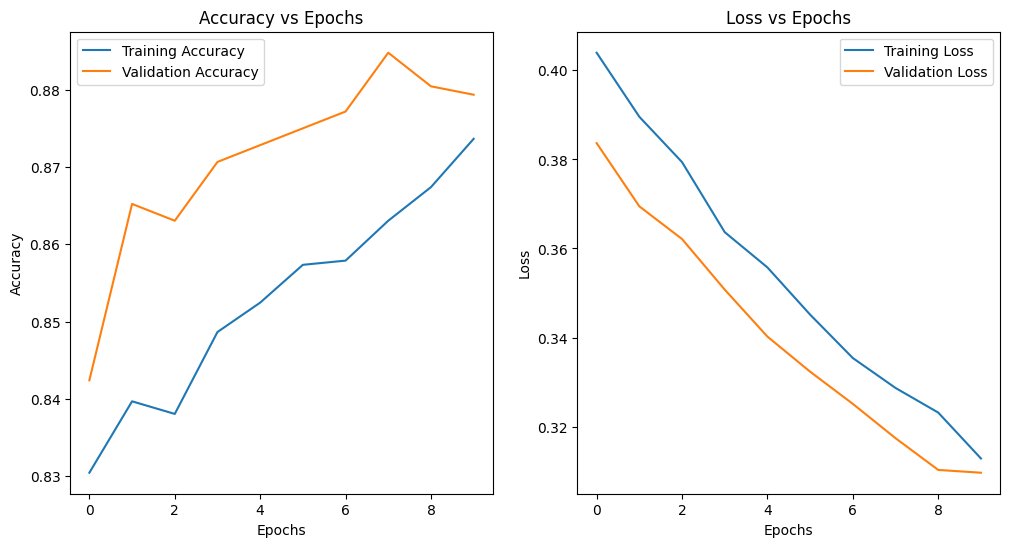

In [26]:
# Train the best model
history_best = best_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32,
    callbacks=[early_stopping]
)

# Visualization of the training and validation accuracy and loss
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Fine-tuning the VGG16 Model

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.8714 - loss: 0.3045 - val_accuracy: 0.8859 - val_loss: 0.3035 - learning_rate: 1.0000e-05
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 409s 4s/step - accuracy: 0.8758 - loss: 0.3056 - val_accuracy: 0.8837 - val_loss: 0.3025 - learning_rate: 1.0000e-05
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 420s 4s/step - accuracy: 0.8770 - loss: 0.3125 - val_accuracy: 0.8848 - val_loss: 0.3015 - learning_rate: 1.0000e-05
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.8650 - loss: 0.3162 - val_accuracy: 0.8826 - val_loss: 0.3006 - learning_rate: 1.0000e-05
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 383s 3s/step - accuracy: 0.8845 - loss: 0.3034 - val_accuracy: 0.8826 - val_loss: 0.2999 - learning_rate: 1.0000e-05
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 402s 4s/step - accuracy: 0.8815 - loss: 0.3006 - val_accuracy: 0.8848 - val_loss: 0.2992 - learning_rate: 1.0000e-05
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 629s 5s/step - acc

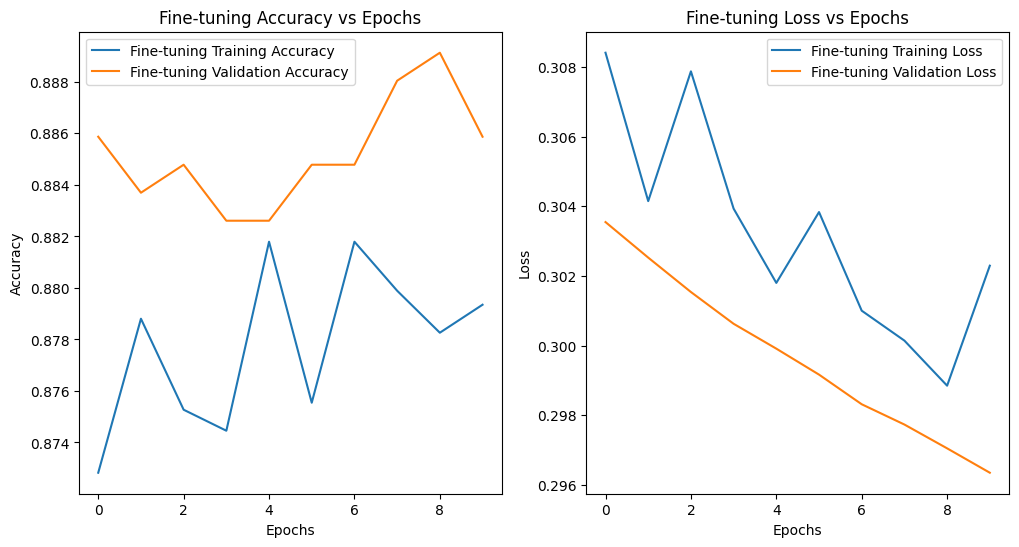

In [28]:
# Unfreeze the top layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-4]:  # Freeze all but the last 4 layers
    layer.trainable = False

# Recompile the model with a low learning rate for fine-tuning
best_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune the model with training
history_finetune = best_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32,
    callbacks=[early_stopping, ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)]
)

# Visualize the fine-tuning results
plt.figure(figsize=(12, 6))

# Accuracy plot for fine-tuning
plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Fine-tuning Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Fine-tuning Validation Accuracy')
plt.title('Fine-tuning Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot for fine-tuning
plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Fine-tuning Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Fine-tuning Validation Loss')
plt.title('Fine-tuning Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


gridsearch cnn

In [ ]:
#tuning cnn / hyperparams  (nour grid search
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf
import itertools

# Define the CNN model creation function
def create_model(filters=32, kernel_size=(3,3), dropout_rate=0.5, dense_units=128):
    model = Sequential([
        Conv2D(filters, kernel_size, activation='relu', input_shape=(224, 224, 3)),
        MaxPooling2D(2,2),
        Conv2D(filters*2, kernel_size, activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(filters*4, kernel_size, activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Define hyperparameter options
filters_options = [16, 32, 64]
kernel_size_options = [(3,3), (5,5)]
dropout_rate_options = [0.3, 0.5, 0.7]
dense_units_options = [64, 128, 256]
batch_size_options = [16, 32]
epochs_options = [5, 10]

# Store results
best_accuracy = 0
best_params = None

# Manual grid search
for filters, kernel_size, dropout_rate, dense_units, batch_size, epochs in itertools.product(
    filters_options, kernel_size_options, dropout_rate_options, dense_units_options,
    batch_size_options, epochs_options):

    print(f"Testing: filters={filters}, kernel_size={kernel_size}, dropout_rate={dropout_rate}, "
          f"dense_units={dense_units}, batch_size={batch_size}, epochs={epochs}")

    model = create_model(filters=filters, kernel_size=kernel_size,
                         dropout_rate=dropout_rate, dense_units=dense_units)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=0.2, verbose=0)

    val_accuracy = max(history.history['val_accuracy'])

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_params = {
            'filters': filters,
            'kernel_size': kernel_size,
            'dropout_rate': dropout_rate,
            'dense_units': dense_units,
            'batch_size': batch_size,
            'epochs': epochs
        }
        print(f"New best accuracy: {best_accuracy} with params {best_params}")

# Train the best model on full training set
best_model = create_model(**{k: v for k, v in best_params.items() if k in ['filters', 'kernel_size', 'dropout_rate', 'dense_units']})
best_model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], verbose=1)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Best parameters: {best_params}")
print(f"Test accuracy of the best model: {test_accuracy}")

Testing: filters=16, kernel_size=(3, 3), dropout_rate=0.3, dense_units=64, batch_size=16, epochs=5


C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


New best accuracy: 0.95923912525177 with params {'filters': 16, 'kernel_size': (3, 3), 'dropout_rate': 0.3, 'dense_units': 64, 'batch_size': 16, 'epochs': 5}
Testing: filters=16, kernel_size=(3, 3), dropout_rate=0.3, dense_units=64, batch_size=16, epochs=10
New best accuracy: 0.9728260636329651 with params {'filters': 16, 'kernel_size': (3, 3), 'dropout_rate': 0.3, 'dense_units': 64, 'batch_size': 16, 'epochs': 10}
Testing: filters=16, kernel_size=(3, 3), dropout_rate=0.3, dense_units=64, batch_size=32, epochs=5
Testing: filters=16, kernel_size=(3, 3), dropout_rate=0.3, dense_units=64, batch_size=32, epochs=10
Testing: filters=16, kernel_size=(3, 3), dropout_rate=0.3, dense_units=128, batch_size=16, epochs=5
Testing: filters=16, kernel_size=(3, 3), dropout_rate=0.3, dense_units=128, batch_size=16, epochs=10


In [ ]:
#tuning cnn / meriem manual tuning
# Load and preprocess data
data = []  # List to store image arrays
labels = []  # List to store corresponding binary labels

# Iterate over categories to load images and assign labels
for category in categories:
    path = os.path.join(dataset_path, category)  # Full path to category folder
    label = categories.index(category)  # Assign 0 for "Healthy", 1 for "Brain Tumor"
    for img_name in os.listdir(path):  # Loop through all images in the folder
        img = tf.keras.utils.load_img(os.path.join(path, img_name), target_size=(IMG_SIZE, IMG_SIZE))  # Load and resize image
        img_array = tf.keras.utils.img_to_array(img)  # Convert image to NumPy array
        data.append(img_array)  # Add image array to data list
        labels.append(label)  # Add corresponding label to labels list

# Convert lists to NumPy arrays
data = np.array(data) / 255.0  # Convert to array and normalize pixel values to [0, 1]
labels = np.array(labels)  # Convert labels to array, keeping them binary (0s and 1s)

# Split into train and test sets
# test_size=0.2 means 20% for testing, stratify ensures balanced classes in split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

# Verify shapes to ensure data consistency
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")  # Check training data shapes
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")  # Check test data shapes

# Define the tuned CNN model
model = Sequential([  # Sequential model to stack layers
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),  # Explicit input layer specifying image shape (224x224x3)
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),  # 32 filters, 3x3 kernel, ReLU activation, L2 regularization
    BatchNormalization(),  # Normalize activations to stabilize training
    MaxPooling2D((2, 2)),  # Reduce spatial dimensions by half
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),  # 64 filters with regularization
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),  # 128 filters for deeper feature extraction
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),  # Flatten the 3D feature maps into a 1D vector
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),  # Fully connected layer with 128 units
    Dropout(0.5),  # Drop 50% of units during training to prevent overfitting
    Dense(1, activation='sigmoid')  # Output layer for binary classification (0 or 1)
])

# Compile the model
optimizer = Adam(learning_rate=0.001)  # Adam optimizer with initial learning rate of 0.001
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])  # Binary cross-entropy for binary classification

# Learning rate reduction callback
lr_scheduler = ReduceLROnPlateau(  # Reduce learning rate when validation loss plateaus
    monitor='val_loss',  # Monitor validation loss
    factor=0.5,  # Reduce learning rate by half
    patience=3,  # Wait 3 epochs before reducing
    min_lr=1e-6,  # Minimum learning rate limit
    verbose=1  # Print updates during training
)

# Compute class weights to handle potential imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)  # Balance weights based on class frequency
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}  # Dictionary for class 0 (Healthy) and 1 (Tumor)
print("Class Weights:", class_weights_dict)  # Display computed weights

# Train the model
history = model.fit(
    X_train, y_train,  # Training data and labels
    validation_data=(X_test, y_test),  # Validation data for monitoring performance
    epochs=20,  # Number of training epochs
    batch_size=32,  # Batch size for mini-batch gradient descent
    callbacks=[lr_scheduler],  # Apply learning rate scheduler
    class_weight=class_weights_dict  # Apply class weights to balance training
)

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy over epochs
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Tuned CNN Model Accuracy')  # Title of the plot
plt.legend()  # Add legend to distinguish lines
plt.show()  # Display the plot

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss over epochs
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Tuned CNN Model Loss')  # Title of the plot
plt.legend()  
plt.show()  # Display the plot